# POPTop at M8 - compare / adjust to other gear

This unit does not seem to have the right calibration constants... although the shape looks to be good (bad offset?

- bottom data seems to end in january, but popup seems to be in May?

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

In [62]:
sample_data_dir = '/Users/bell/Programs/EcoFOCIpy/'
user_data_dir = '/Users/bell/ecoraid/2019/Moorings/19bs8a/'

In [63]:
###############################################################
# edit to point to {instrument sepcific} raw datafile 
datafile = user_data_dir+'rawconverted/19BSPOPTOP-8A/'
instrument = 'PopTop 19M8'
mooring_meta_file = user_data_dir+'logs/19BS-8A.yaml'
inst_meta_file = sample_data_dir+'staticdata/instr_metaconfig/puf_cf.yaml'
institution_meta_file = sample_data_dir+'staticdata/institutional_meta_example.yaml' #include uaf?
inst_shortname = 'puf'


In [64]:
bottom = pd.read_csv(datafile+'4010_bottom_data.csv',parse_dates=True,index_col='datetime')
ice = pd.read_csv(datafile+'4010_ice_data.csv',parse_dates=True,index_col='datetime')
# sst = pd.read_csv(datafile+'P-8A_sst_data.csv',parse_dates=True,index_col='datetime')

<Axes: xlabel='datetime'>

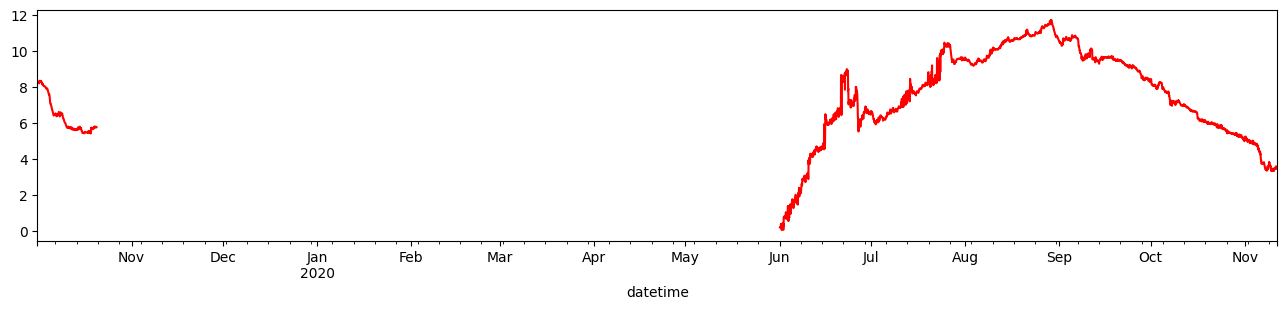

In [65]:
fig, ax = plt.subplots(1,figsize=(16, 3))
bottom.fr_temp.plot(ax=ax,color='r')
ice.fr_temp.plot(ax=ax,color='r')
# sst.fr_temp.plot(ax=ax,color='r')

In [66]:
# plot against local mtr

In [67]:
mtr_data = pd.read_csv(user_data_dir+'initial_archive/19bs8a_mt4050_0017m.csv',parse_dates=True,index_col='time')

<Axes: xlabel='datetime'>

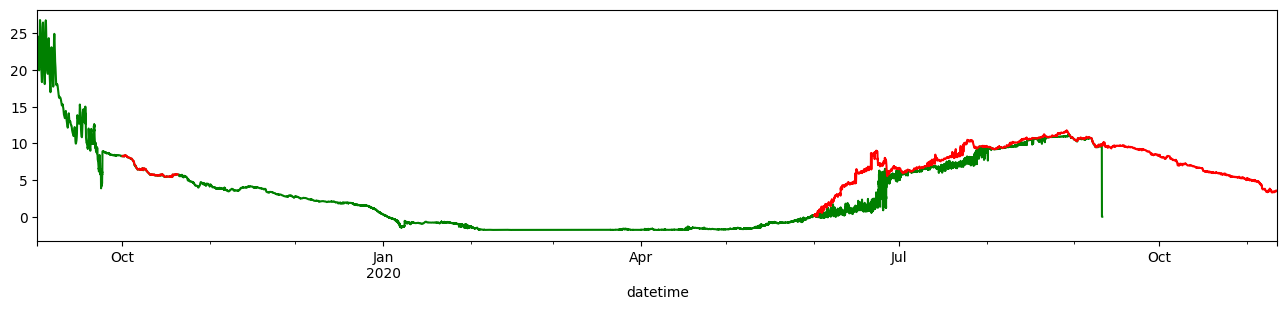

In [68]:
fig, ax = plt.subplots(1,figsize=(16, 3))
mtr_data.temperature.plot(ax=ax,color='g')
(bottom.fr_temp).plot(ax=ax,color='r')
(ice.fr_temp).plot(ax=ax,color='r')
# (sst.fr_temp-178.2).plot(ax=ax,color='r')


In [69]:
bottom.index.name = 'date_time'
bottom.drop(['Unnamed: 0','time'],inplace=True,axis=1)
bottom.rename(columns={'fr_temp':'temperature'},inplace=True)

In [70]:
# save two files for netcdf - pre and post pop

import yaml
import EcoFOCIpy.io.ncCFsave as ncCFsave

## Add Deployment meta information

Two methods are available (if comming from python2 world - ordereddict was important... in py38 a dictionary is inherently ordered)

In [86]:
#just a dictionary of dictionaries - simple
with open(mooring_meta_file) as file:
    mooring_config = yaml.full_load(file)

In [87]:
#just a dictionary of dictionaries - simple
with open(institution_meta_file) as file:
    institution_config = yaml.full_load(file)

## Add Instrument meta information

Time, depth, lat, lon should be added regardless (always our coordinates) but for a mooring site its going to be a (1,1,1,t) dataset
The variables of interest should be read from the data file and matched to a key for naming.  That key is in the inst_config file seen below and should represent common conversion names in the raw data

In [73]:
with open(inst_meta_file) as file:
    inst_config = yaml.full_load(file)

In [74]:
# Add meta data and prelim processing based on meta data
# Convert to xarray and add meta information - save as CF netcdf file
# pass -> data, instmeta, depmeta
puf_deep_wop_nc = ncCFsave.EcoFOCI_CFnc(df=bottom, 
                                instrument_yaml=inst_config, 
                                operation_yaml=mooring_config,
                                operation_type='mooring', 
                                instrument_id=instrument, 
                                inst_shortname=inst_shortname)
puf_deep_wop_nc

At this point, you could save your file with the `.xarray2netcdf_save()` method and have a functioning dataset.... but it would be very simple with no additional qc, meta-data, or tuned parameters for optimizing software like ferret or erddap.

In [75]:
# expand the dimensions and coordinate variables
# renames them appropriatley and prepares them for meta-filled values
puf_deep_wop_nc.expand_dimensions()

In [76]:
puf_deep_wop_nc.variable_meta_data(variable_keys=list(bottom.columns.values),drop_missing=True)
puf_deep_wop_nc.temporal_geospatioal_meta_data(depth='designed')
#adding dimension meta needs to come after updating the dimension values... BUG?
puf_deep_wop_nc.dimension_meta_data(variable_keys=['depth','latitude','longitude'])

The following steps can happen in just about any order and are all meta-data driven.  Therefore, they are not required to have a functioning dataset, but they are required to have a well described dataset

In [77]:
#add global attributes
puf_deep_wop_nc.deployment_meta_add()
puf_deep_wop_nc.get_xdf()

#add instituitonal global attributes
puf_deep_wop_nc.institution_meta_add(institution_yaml=institution_config)

#add instrument global attributes
puf_deep_wop_nc.instrument_meta_data()

#add creation date/time - provenance data
puf_deep_wop_nc.provinance_meta_add()

#provide intial qc status field
puf_deep_wop_nc.qc_status(qc_status='unknown')

## Save CF Netcdf files

Currently stick to netcdf3 classic... but migrating to netcdf4 (default) may be no problems for most modern purposes.  Its easy enough to pass the `format` kwargs through to the netcdf api of xarray.

In [78]:
# combine trim (not mandatory) and filename together (saves to test.nc without name)

depth = str(int(mooring_config['Instrumentation'][instrument]['ActualDepth'])).zfill(4)
# mooring_yaml['Instrumentation'][self.instrument_id]['DesignedDepth'])).zfill(4) #<-- alternative
filename = "".join(mooring_config['MooringID'].split('-')).lower()+'_'+inst_shortname+'_'+depth+'m.nc'
puf_deep_wop_nc.xarray2netcdf_save(xdf = puf_deep_wop_nc.autotrim_time(),
                           filename=filename,format="NETCDF3_CLASSIC")

# don't trim the data and pass your own filename
# sbe37_wop_nc.xarray2netcdf_save(xdf = sbe37_wop_nc.get_xdf(),
#                            filename=filename,format="NETCDF4_CLASSIC")

### Under Ice is Shallow -

In [88]:
ice.index.name = 'date_time'
ice.drop(['Unnamed: 0','time'],inplace=True,axis=1)
ice.rename(columns={'fr_temp':'temperature'},inplace=True)

KeyError: "['Unnamed: 0', 'time'] not found in axis"

## Add Instrument meta information

Time, depth, lat, lon should be added regardless (always our coordinates) but for a mooring site its going to be a (1,1,1,t) dataset
The variables of interest should be read from the data file and matched to a key for naming.  That key is in the inst_config file seen below and should represent common conversion names in the raw data

In [89]:
with open(inst_meta_file) as file:
    inst_config = yaml.full_load(file)

In [90]:
# Add meta data and prelim processing based on meta data
# Convert to xarray and add meta information - save as CF netcdf file
# pass -> data, instmeta, depmeta
puf_shallow_wop_nc = ncCFsave.EcoFOCI_CFnc(df=ice, 
                                instrument_yaml=inst_config, 
                                operation_yaml=mooring_config,
                                operation_type='mooring', 
                                instrument_id=instrument, 
                                inst_shortname=inst_shortname)
puf_shallow_wop_nc

At this point, you could save your file with the `.xarray2netcdf_save()` method and have a functioning dataset.... but it would be very simple with no additional qc, meta-data, or tuned parameters for optimizing software like ferret or erddap.

In [91]:
# expand the dimensions and coordinate variables
# renames them appropriatley and prepares them for meta-filled values
puf_shallow_wop_nc.expand_dimensions()

In [92]:
puf_shallow_wop_nc.variable_meta_data(variable_keys=list(ice.columns.values),drop_missing=True)
puf_shallow_wop_nc.temporal_geospatioal_meta_data(depth='designed')
#adding dimension meta needs to come after updating the dimension values... BUG?
puf_shallow_wop_nc.dimension_meta_data(variable_keys=['depth','latitude','longitude'])

The following steps can happen in just about any order and are all meta-data driven.  Therefore, they are not required to have a functioning dataset, but they are required to have a well described dataset

In [93]:
#add global attributes
puf_shallow_wop_nc.deployment_meta_add()
puf_shallow_wop_nc.get_xdf()

#add instituitonal global attributes
puf_shallow_wop_nc.institution_meta_add(institution_yaml=institution_config)

#add instrument global attributes
puf_shallow_wop_nc.instrument_meta_data()

#add creation date/time - provenance data
puf_shallow_wop_nc.provinance_meta_add()

#provide intial qc status field
puf_shallow_wop_nc.qc_status(qc_status='unknown')

## Save CF Netcdf files

Currently stick to netcdf3 classic... but migrating to netcdf4 (default) may be no problems for most modern purposes.  Its easy enough to pass the `format` kwargs through to the netcdf api of xarray.

In [94]:
# combine trim (not mandatory) and filename together (saves to test.nc without name)

depth = str(int(mooring_config['Instrumentation'][instrument]['ActualDepth'])).zfill(4)
# mooring_yaml['Instrumentation'][self.instrument_id]['DesignedDepth'])).zfill(4) #<-- alternative
filename = "".join(mooring_config['MooringID'].split('-')).lower()+'_'+inst_shortname+'_'+depth+'m.nc'
puf_shallow_wop_nc.xarray2netcdf_save(xdf = puf_shallow_wop_nc.autotrim_time(),
                           filename=filename,format="NETCDF3_CLASSIC")

# don't trim the data and pass your own filename
# sbe37_wop_nc.xarray2netcdf_save(xdf = sbe37_wop_nc.get_xdf(),
#                            filename=filename,format="NETCDF4_CLASSIC")